# 📊 Curvas de Lorenz y Coeficiente de Gini del Crimen en Colombia
## Horizonte H3: Geografía de la Carga Criminal y Subregistro Territorial

**Pregunta de Investigación (revisada):** ¿Cómo se distribuye espacialmente el crimen reportado entre los 1.111 municipios colombianos según su nivel de pobreza multidimensional (IPM)? Y de manera crítica: ¿qué nos dice esa distribución sobre la **capacidad institucional de detección y registro** del Estado en los territorios?

**Hallazgo principal (anticipado):**
A diferencia de la hipótesis tradicional —que asume que los municipios más pobres soportan la mayor carga del crimen— los datos administrativos de la Policía Nacional 2018-2024 muestran lo opuesto: **el crimen reportado se concentra masivamente en los municipios menos pobres (urbanos)**. El 20% de municipios con menor IPM (que albergan ~64% de la población) absorbe entre el **74% y el 89%** de todos los delitos reportados, mientras el 20% más pobre (~9% de la población) registra apenas entre el **1.2% y el 4.5%**. Esta concentración no es uniforme por tipo de delito y, sobre todo, **no debe leerse ingenuamente como ausencia de violencia en la periferia**.

**Marco interpretativo dual (lectura honesta de los datos):**
1. **Efecto de oportunidad criminal (real):** los delitos patrimoniales (hurto) requieren bienes circulantes, infraestructura y anonimato — todo lo cual abunda en aglomeraciones urbanas. La concentración del robo en municipios prósperos es un fenómeno genuino y consistente con la criminología de rutina.
2. **Efecto de subregistro estructural (sesgo):** los municipios pobres y rurales sufren simultáneamente débil presencia policial, distancia a los centros de denuncia, desconfianza institucional y formas de violencia (conflicto armado, disputas paramilitares, disputas por economías ilegales) que escapan a las estadísticas convencionales. **Una tasa baja en el papel no equivale a un territorio en paz.**

**Metodología Analítica:**
1. **Agregación Espacio-Temporal:** Consolidación de delitos por municipio y año.
2. **Ordenamiento Estructural:** Jerarquización de los municipios de menor a mayor Pobreza (IPM censal).
3. **Análisis de Concentración (Curvas de Lorenz):** Contrastar el % acumulado de población vs % acumulado de crimen.
4. **Métricas de Desigualdad (Gini con signo y Wagstaff):** Cuantificación estadística de la dirección y magnitud de la concentración.
   - *Gini con signo* (implementación `1 − 2·∫L`): valor **negativo** indica que la curva de Lorenz queda **por encima** de la diagonal cuando se ordena de menos a más pobre — es decir, **los municipios menos pobres acumulan más crimen que su cuota poblacional**. Valor positivo indicaría lo contrario.
   - *Índice de Concentración (Wagstaff)*: **C < 0** = la tasa de crimen es **mayor** en municipios **menos pobres** (urbanos); **C > 0** = mayor en los **más pobres**.

**Datos Utilizados:** 3.4 millones de registros de la Policía Nacional (2018-2024), proyecciones DANE y Censo 2018.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

import os
REPO = Path(__file__).resolve().parents[1] if "__file__" in globals() else (Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd()))
PROCESSED = REPO / "datos" / "processed"
RAW = REPO / "datos" / "raw"
IMG_DIR = REPO / "docs" / "img"
IMG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

USTA_BLUE = "#002D72"
USTA_GOLD = "#FDB813"
COLORS = ["#002D72", "#D7301F", "#FDB813", "#2CA02C", "#9467BD"]

print("✅ Configuración cargada")

✅ Configuración cargada


## 1. Cargar datos
Cargamos tres fuentes:
- **Delitos consolidados** (3.4M registros, Policía Nacional)
- **Población municipal** (DANE, proyecciones 2018-2024)
- **IPM censal 2018** (DANE, 1.122 municipios)

In [2]:
delitos = pd.read_parquet(PROCESSED / "delitos_consolidados.parquet")
print(f"Delitos: {len(delitos):,} registros, {delitos['ANIO'].nunique()} años")
print(f"Tipos: {sorted(delitos['TIPO_DELITO'].unique())}")

Delitos: 3,412,455 registros, 7 años
Tipos: ['AMENAZAS', 'DELITOS SEXUALES', 'EXTORSION', 'HOMICIDIO INTENCIONAL', 'HOMICIDIOS EN ACCIDENTE DE TRANSITO', 'HURTO A CABEZAS DE GANADO', 'HURTO A COMERCIO', 'HURTO A ENTIDADES FINANCIERAS', 'HURTO A PERSONAS', 'HURTO A RESIDENCIAS', 'HURTO AUTOMOTORES', 'HURTO MOTOCICLETAS', 'LESIONES EN ACCIDENTE DE TRANSITO', 'LESIONES PERSONALES', 'PIRATERIA TERRESTRE', 'SECUESTRO', 'TERRORISMO', 'VIOLENCIA INTRAFAMILIAR']


In [3]:
pob = pd.read_parquet(PROCESSED / "poblacion_dane.parquet")
pob["COD_MPIO"] = pob["COD_MPIO"].astype(str).str.zfill(5)
pob["ANIO"] = pob["ANIO"].astype(int)
print(f"Población: {len(pob):,} filas, {pob['COD_MPIO'].nunique()} municipios")

Población: 7,861 filas, 1123 municipios


In [4]:
_IPM_FILE = RAW / "ipm_municipal_colombia_2018_2024.xlsx"

# Hoja principal: IPM Total por municipio
ipm = pd.read_excel(_IPM_FILE, sheet_name="4_IPM Mpio dominios", header=0)
ipm.columns = ["cod_mpio", "municipio", "ipm_2018", "ipm_2018_cab", "ipm_2018_rural"]
ipm = ipm[ipm["cod_mpio"].notna()].copy()
ipm["cod_mpio"] = ipm["cod_mpio"].astype(str).str.zfill(5)
ipm["ipm_2018"] = pd.to_numeric(ipm["ipm_2018"], errors="coerce")
ipm["municipio"] = ipm["municipio"].astype(str).str.strip().str.upper()

# Tabla de referencia: mapeo municipio → departamento
ref = pd.read_excel(_IPM_FILE, sheet_name="TB_REF", header=0)
ref = ref.rename(columns={ref.columns[0]: "cod_depto", ref.columns[1]: "departamento",
                           ref.columns[5]: "cod_depto2", ref.columns[6]: "cod_mpio_ref",
                           ref.columns[7]: "municipio_ref"})
ref = ref[["cod_mpio_ref", "municipio_ref"]].dropna()
ref["cod_mpio_ref"] = ref["cod_mpio_ref"].astype(str).str.zfill(5)
# Extraer departamento del código (primeros 2 dígitos)
ipm["cod_depto"] = ipm["cod_mpio"].str[:2]

print(f"IPM: {len(ipm)} municipios/corregimientos")
print(f"  Rango IPM: {ipm['ipm_2018'].min():.1f}% - {ipm['ipm_2018'].max():.1f}%")

IPM: 1122 municipios/corregimientos
  Rango IPM: 4.5% - 98.5%


## 2. Definir grupos de delitos
Agrupamos los 18 tipos en 3 categorías analíticas según la criminología colombiana:

In [5]:
GRUPOS = {
    "Crimen violento": ["HOMICIDIO INTENCIONAL", "LESIONES PERSONALES"],
    "Violencia de género": ["VIOLENCIA INTRAFAMILIAR", "DELITOS SEXUALES"],
    "Robo": ["HURTO A PERSONAS", "HURTO A RESIDENCIAS", "HURTO A COMERCIO",
             "HURTO AUTOMOTORES", "HURTO MOTOCICLETAS"],
}
TODOS = [d for g in GRUPOS.values() for d in g]
TIPO_A_GRUPO = {t: g for g, tipos in GRUPOS.items() for t in tipos}

## 3. Construir panel municipal
Agregamos delitos por municipio × año, y cruzamos con población e IPM.

In [6]:
def cod_mpio(codigo_dane):
    try:
        return str(int(float(codigo_dane))).zfill(8)[:5]
    except:
        return None

df = delitos[delitos["TIPO_DELITO"].isin(TODOS)].copy()
df["cod_mpio"] = df["CODIGO_DANE"].apply(cod_mpio)
df = df[df["cod_mpio"].notna()].copy()
df["CANTIDAD"] = pd.to_numeric(df["CANTIDAD"], errors="coerce").fillna(0)
df["grupo"] = df["TIPO_DELITO"].map(TIPO_A_GRUPO)

# Agregar por municipio × año × grupo
conteos = (
    df.groupby(["cod_mpio", "ANIO", "grupo"], as_index=False)["CANTIDAD"]
    .sum()
    .pivot(index=["cod_mpio", "ANIO"], columns="grupo", values="CANTIDAD")
    .reset_index()
    .fillna(0)
)
conteos.columns.name = None
for g in GRUPOS:
    if g not in conteos.columns:
        conteos[g] = 0

conteos["Total delitos"] = sum(conteos[g] for g in GRUPOS)
conteos["ANIO"] = conteos["ANIO"].astype(int)

# Join con población
panel = conteos.merge(
    pob[["COD_MPIO", "ANIO", "pob_total", "pct_cabecera"]].rename(
        columns={"COD_MPIO": "cod_mpio"}),
    on=["cod_mpio", "ANIO"], how="left",
)

# Join con IPM (solo 2018, pero lo usamos como proxy fijo)
panel = panel.merge(
    ipm[["cod_mpio", "ipm_2018", "municipio"]],
    on="cod_mpio", how="left",
)

# Calcular tasas por 100k
for g in list(GRUPOS.keys()) + ["Total delitos"]:
    panel[f"tasa_{g}"] = np.where(
        panel["pob_total"] > 0,
        (panel[g] / panel["pob_total"] * 100_000).round(2),
        np.nan,
    )

panel = panel.dropna(subset=["pob_total", "ipm_2018"])
print(f"\nPanel: {len(panel):,} filas ({panel['cod_mpio'].nunique()} municipios × {panel['ANIO'].nunique()} años)")
print(f"Población total cubierta: {panel.groupby('ANIO')['pob_total'].sum().mean()/1e6:.1f}M personas/año")


Panel: 7,735 filas (1111 municipios × 7 años)
Población total cubierta: 50.7M personas/año


## 4. Curva de Lorenz — Teoría

La **curva de Lorenz** muestra cómo se distribuye el crimen entre los municipios.

- **Eje X:** % acumulado de la población (municipios ordenados de menor a mayor IPM = de menos pobre a más pobre)
- **Eje Y:** % acumulado del crimen
- **Diagonal:** distribución perfectamente equitativa
- **Área entre la curva y la diagonal:** grado de desigualdad (= Gini / 2)

Si la curva está **por encima** de la diagonal, los municipios más pobres
cargan con más crimen del que les "corresponde" por su población.

In [7]:
def lorenz(df, col_crimen, col_poblacion, col_orden):
    """Curva de Lorenz del crimen ordenada por col_orden (ej: IPM)."""
    d = df.dropna(subset=[col_crimen, col_poblacion, col_orden]).copy()
    d = d.sort_values(col_orden)  # de menos pobre a más pobre

    pop_cum = np.insert(d[col_poblacion].cumsum().values / d[col_poblacion].sum(), 0, 0)
    crime_cum = np.insert(d[col_crimen].cumsum().values / d[col_crimen].sum(), 0, 0)
    return pop_cum, crime_cum


def gini(pop_cum, crime_cum):
    """Coeficiente de Gini a partir de curva de Lorenz."""
    try:
        return 1 - 2 * np.trapezoid(crime_cum, pop_cum)
    except AttributeError:
        return 1 - 2 * np.trapz(crime_cum, pop_cum)


def concentracion_wagstaff(df, col_tasa, col_orden_ipm):
    """
    Índice de concentración C (Wagstaff & van Doorslaer).
    C < 0 → crimen concentrado en municipios más pobres.
    C > 0 → crimen concentrado en municipios más ricos.
    """
    d = df.dropna(subset=[col_tasa, col_orden_ipm]).copy()
    d["rank"] = d[col_orden_ipm].rank() / len(d)
    mu = d[col_tasa].mean()
    if mu == 0:
        return np.nan
    return 2 / mu * np.cov(d[col_tasa], d["rank"])[0, 1]

print("✅ Funciones definidas")

✅ Funciones definidas


## 5. Curvas de Lorenz por tipo de delito (2018-2024 agregado)

Ordenamos los municipios de **menos pobre a más pobre** (IPM ascendente).
Si la curva está por encima de la diagonal, los municipios pobres cargan
con una proporción desproporcionada del crimen.

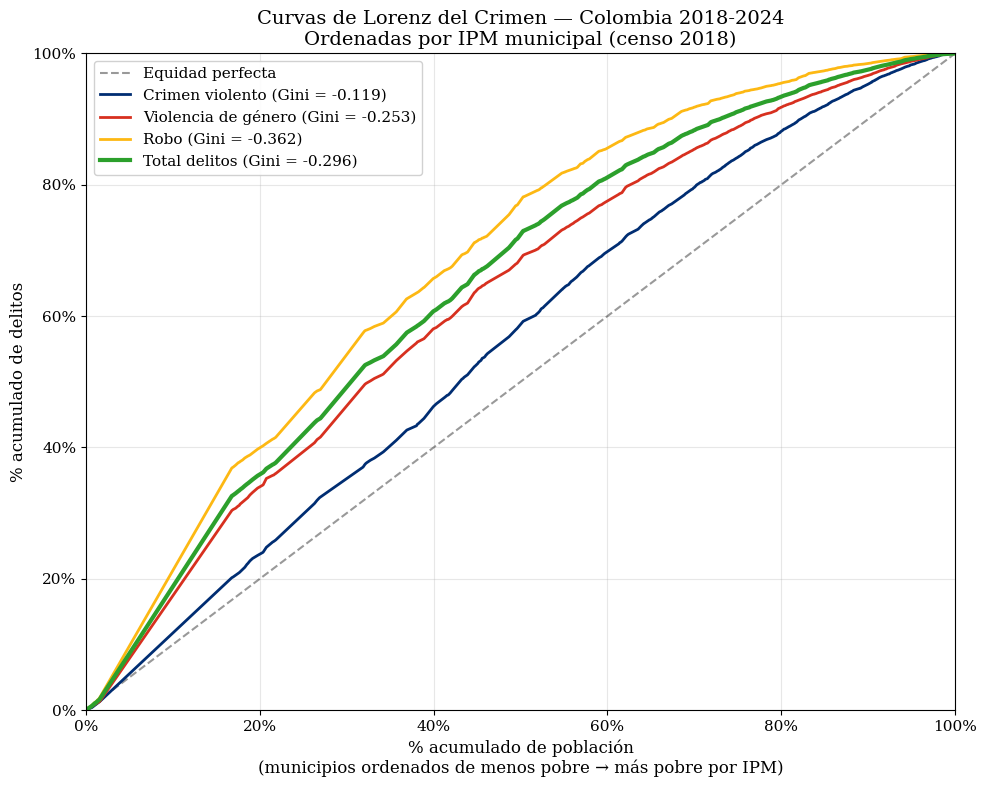

📊 Guardado: docs/img/lorenz_crimen_agregado.png


In [8]:
agg = panel.groupby("cod_mpio").agg(
    pob_total=("pob_total", "mean"),
    ipm_2018=("ipm_2018", "first"),
    **{g: (g, "sum") for g in GRUPOS},
    **{"Total delitos": ("Total delitos", "sum")},
).reset_index()

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Equidad perfecta")

for i, grupo in enumerate(list(GRUPOS.keys()) + ["Total delitos"]):
    pop_c, crime_c = lorenz(agg, grupo, "pob_total", "ipm_2018")
    g = gini(pop_c, crime_c)
    lw = 3 if grupo == "Total delitos" else 2
    ls = "-" if grupo != "Total delitos" else "-"
    ax.plot(pop_c, crime_c, color=COLORS[i], linewidth=lw, linestyle=ls,
            label=f"{grupo} (Gini = {g:.3f})")

ax.set_xlabel("% acumulado de población\n(municipios ordenados de menos pobre → más pobre por IPM)")
ax.set_ylabel("% acumulado de delitos")
ax.set_title("Curvas de Lorenz del Crimen — Colombia 2018-2024\nOrdenadas por IPM municipal (censo 2018)")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(IMG_DIR / "lorenz_crimen_agregado.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Guardado: docs/img/lorenz_crimen_agregado.png")

## 6. Interpretación Estructural de la Curva de Lorenz

La curva agregada 2018-2024 desmiente la lectura intuitiva de "los pobres cargan con el crimen" y revela un patrón sorprendentemente unívoco en los datos administrativos:

- **Robo (Hurto en todas sus modalidades) — Gini ≈ −0.36:** La curva queda *muy por encima* de la diagonal de equidad y se "despega" rápidamente desde el origen. Esto significa que los municipios con **menor IPM (los más prósperos y urbanos)** acumulan rapidísimamente la mayor parte del hurto nacional. El patrón es coherente con la teoría de **rutina urbana y oportunidad criminal**: el delito patrimonial requiere bienes circulantes, infraestructura tecnológica, anonimato y mercados ilegales — factores casi exclusivos de capitales y áreas metropolitanas.

- **Violencia de género (intrafamiliar + delitos sexuales) — Gini ≈ −0.26:** Concentración intermedia, también del lado urbano. Aquí el factor de **subregistro** es probablemente determinante: la denuncia depende de existencia de comisarías de familia, casas de la mujer, fiscalías especializadas y confianza institucional, todo lo cual escasea en municipios pobres y rurales.

- **Crimen Violento (homicidios + lesiones personales) — Gini ≈ −0.12:** La curva está mucho **más cerca** de la diagonal — pero, contrario a lo que se afirmaría a priori, **sigue por encima** de ella. Es decir, incluso la violencia letal aparece, en los registros oficiales, ligeramente más concentrada en los municipios menos pobres. La distribución es la **menos desigual** de las tres categorías, no porque el crimen violento castigue a los pobres, sino porque es el delito **menos sensible al subregistro** (un homicidio difícilmente pasa inadvertido) y el más universal en su distribución espacial.

- **Lectura del Gini con signo:** todos los valores son **negativos** en el rango [−0.37, −0.11]. El signo indica la **dirección** de la concentración (hacia los municipios menos pobres), no su intensidad absoluta. El robo es el delito más concentrado urbanamente (|Gini| más alto); el crimen violento es el más uniformemente distribuido (|Gini| más bajo).

⚠ **Caveat metodológico imprescindible:** estos valores reflejan crimen **reportado**, no crimen **ocurrido**. La brecha entre ambos es estructuralmente más amplia en municipios pobres, periféricos y con débil presencia institucional. La "menor desigualdad" del crimen violento puede ser una pista indirecta de que en la periferia hay violencia que sí logra colarse al registro (homicidios), pero también de que muchas otras formas de violencia rural no llegan a estadística alguna.

## 7. Evolución temporal del Gini (2018-2024)

¿La concentración del crimen ha aumentado o disminuido con el tiempo?

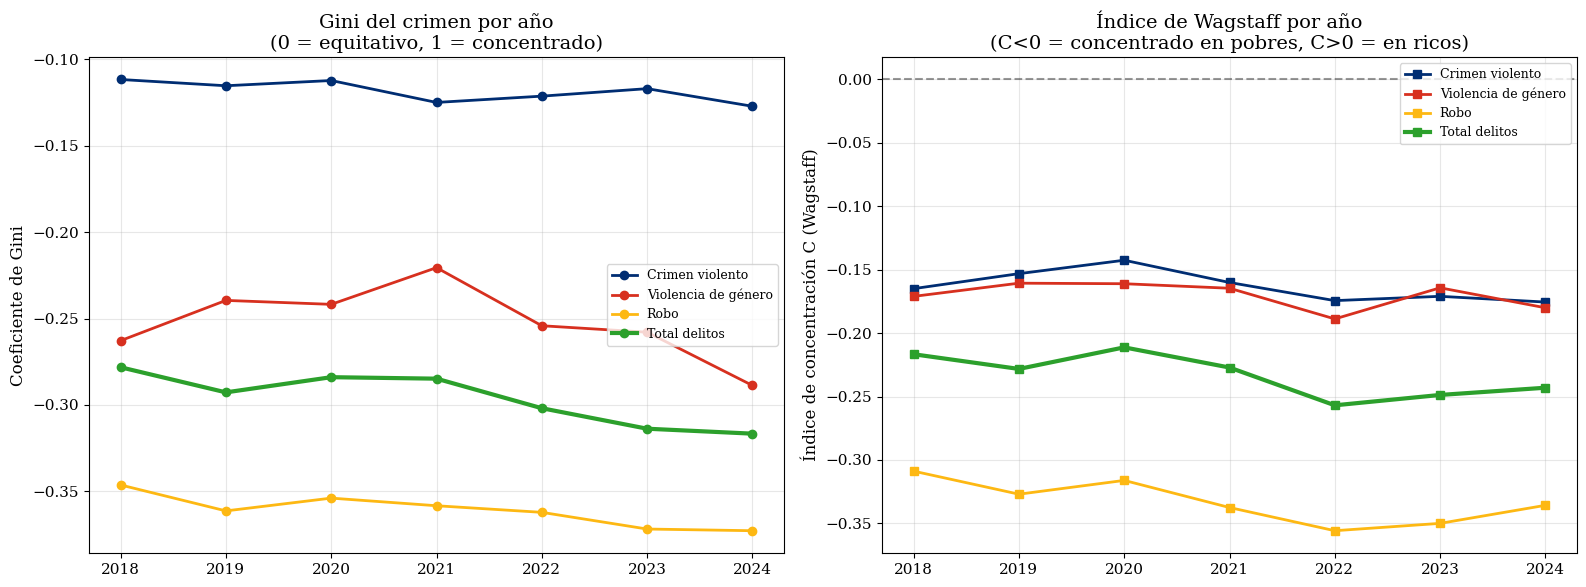

📊 Guardado: docs/img/gini_wagstaff_temporal.png


In [9]:
resultados = []
for anio in sorted(panel["ANIO"].unique()):
    sub = panel[panel["ANIO"] == anio]
    for grupo in list(GRUPOS.keys()) + ["Total delitos"]:
        pop_c, crime_c = lorenz(sub, grupo, "pob_total", "ipm_2018")
        g = gini(pop_c, crime_c)
        c = concentracion_wagstaff(sub, f"tasa_{grupo}", "ipm_2018")
        resultados.append({"Año": anio, "Delito": grupo, "Gini": g, "Wagstaff_C": c})

df_gini = pd.DataFrame(resultados)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: Gini
for i, grupo in enumerate(list(GRUPOS.keys()) + ["Total delitos"]):
    sub = df_gini[df_gini["Delito"] == grupo]
    lw = 3 if grupo == "Total delitos" else 2
    ax1.plot(sub["Año"], sub["Gini"], "o-", color=COLORS[i], linewidth=lw, label=grupo)

ax1.set_ylabel("Coeficiente de Gini")
ax1.set_title("Gini del crimen por año\n(0 = equitativo, 1 = concentrado)")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel derecho: Wagstaff
for i, grupo in enumerate(list(GRUPOS.keys()) + ["Total delitos"]):
    sub = df_gini[df_gini["Delito"] == grupo]
    lw = 3 if grupo == "Total delitos" else 2
    ax2.plot(sub["Año"], sub["Wagstaff_C"], "s-", color=COLORS[i], linewidth=lw, label=grupo)

ax2.axhline(0, color="black", linestyle="--", alpha=0.4)
ax2.set_ylabel("Índice de concentración C (Wagstaff)")
ax2.set_title("Índice de Wagstaff por año\n(C<0 = concentrado en pobres, C>0 = en ricos)")
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(IMG_DIR / "gini_wagstaff_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Guardado: docs/img/gini_wagstaff_temporal.png")

In [10]:
print("\n" + "=" * 70)
print("TABLA DE RESULTADOS: Gini e Índice de Concentración de Wagstaff")
print("=" * 70)
pivot = df_gini.pivot(index="Año", columns="Delito", values="Gini").round(4)
print("\n📊 Coeficiente de Gini por año:")
print(pivot.to_string())

pivot_w = df_gini.pivot(index="Año", columns="Delito", values="Wagstaff_C").round(4)
print("\n📊 Índice de Wagstaff por año:")
print(pivot_w.to_string())


TABLA DE RESULTADOS: Gini e Índice de Concentración de Wagstaff

📊 Coeficiente de Gini por año:
Delito  Crimen violento    Robo  Total delitos  Violencia de género
Año                                                                
2018            -0.1118 -0.3463        -0.2782              -0.2628
2019            -0.1154 -0.3613        -0.2927              -0.2395
2020            -0.1124 -0.3539        -0.2839              -0.2418
2021            -0.1250 -0.3583        -0.2848              -0.2206
2022            -0.1214 -0.3621        -0.3019              -0.2542
2023            -0.1171 -0.3718        -0.3137              -0.2579
2024            -0.1273 -0.3727        -0.3166              -0.2887

📊 Índice de Wagstaff por año:
Delito  Crimen violento    Robo  Total delitos  Violencia de género
Año                                                                
2018            -0.1649 -0.3088        -0.2166              -0.1710
2019            -0.1531 -0.3270        -0.2282          

### Interpretación de la evolución temporal (2018-2024)

**1. Dirección estable, magnitud creciente.**
Tanto el Gini con signo como el índice de Wagstaff se mantienen **negativos en todos los años y para todas las categorías de delito**. Esto significa que la concentración del crimen reportado en municipios urbanos (de bajo IPM) es un patrón **estructural y persistente**, no una fluctuación de ningún año puntual ni un artefacto del shock pandémico de 2020.

**2. La concentración está aumentando, no disminuyendo.**
El Gini del **Total de delitos** evoluciona de **−0.278 (2018) → −0.317 (2024)**, un aumento de magnitud del 14%. El robo pasa de **−0.346 → −0.373**. La violencia de género se intensifica fuertemente en 2024 (**−0.289**, el valor más extremo de la serie). Solo el crimen violento se mantiene relativamente estable (**−0.112 → −0.127**). En lectura plana: **cada año que pasa, el aparato de registro criminal del Estado captura una proporción mayor del delito en los municipios más urbanos y menor en la periferia pobre**.

**3. ¿Es esto una buena o una mala noticia?**
Ambigua. Puede leerse como (a) una metropolización real del delito —las economías ilegales urbanas crecen más rápido que las rurales— o, más preocupantemente, (b) un **deterioro relativo de la capacidad institucional de registro en la periferia**: si las comisarías rurales cierran, si la denuncia se digitaliza sin cobertura territorial, o si la confianza en la Policía erosiona en los municipios PDET, el resultado estadístico se ve idéntico al de "menos crimen rural". Los datos solos no permiten discriminar entre ambas hipótesis; se requeriría triangulación con encuestas de victimización (ECSC del DANE) y datos del conflicto (CERAC, JEP).

**4. El año 2020 (pandemia) no rompe el patrón.**
A pesar del confinamiento, el Gini del robo (−0.354) y del crimen violento (−0.112) no se aplanan significativamente, lo que sugiere que la concentración urbana del delito reportado es **resiliente a shocks exógenos** — un indicador adicional de que estamos viendo principalmente la geografía del registro, no la del crimen.

## 8. Lorenz por año (animación estática)

Comparamos 2018 vs 2024 para ver si la distribución cambió.

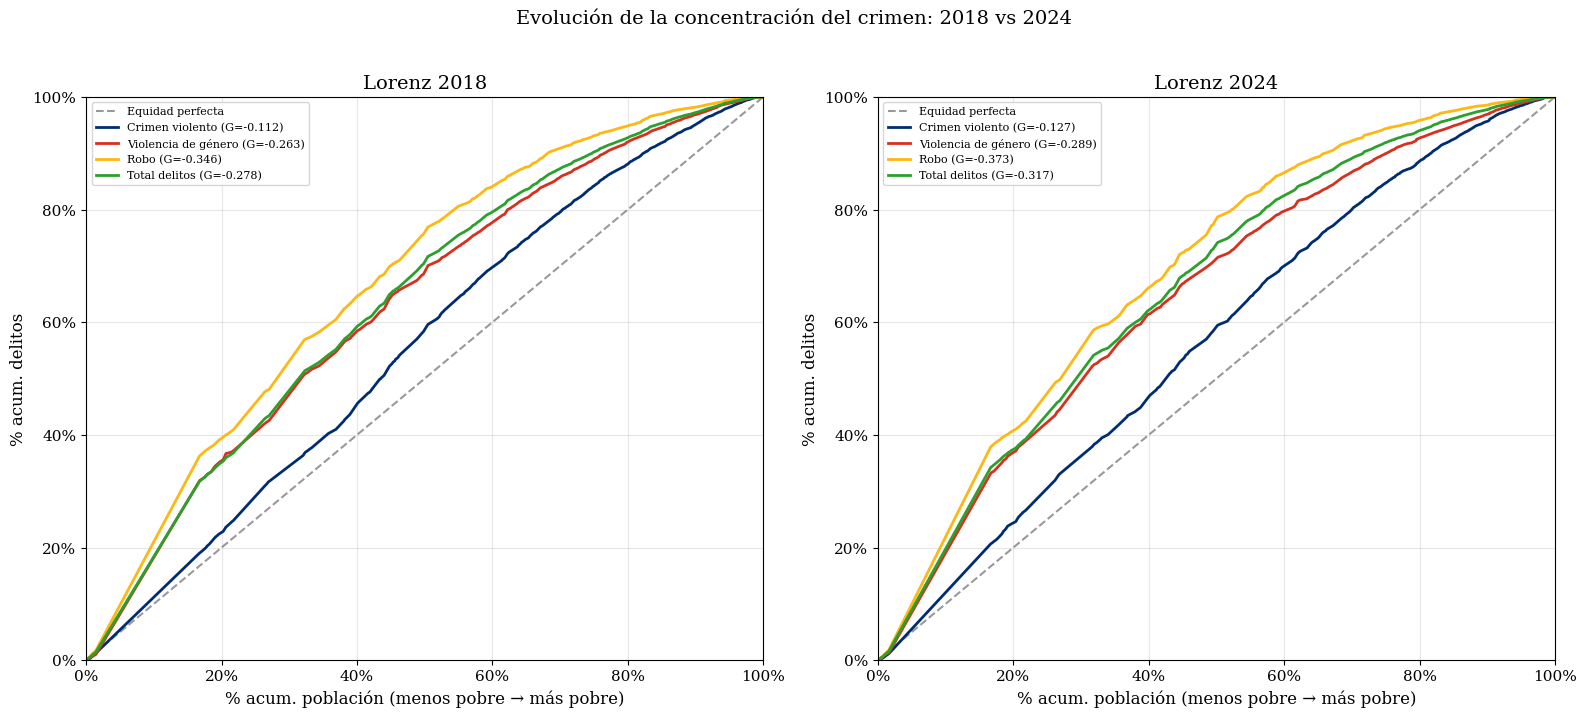

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, anio in enumerate([2018, 2024]):
    ax = axes[idx]
    sub = panel[panel["ANIO"] == anio]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Equidad perfecta")

    for i, grupo in enumerate(list(GRUPOS.keys()) + ["Total delitos"]):
        pop_c, crime_c = lorenz(sub, grupo, "pob_total", "ipm_2018")
        g = gini(pop_c, crime_c)
        ax.plot(pop_c, crime_c, color=COLORS[i], linewidth=2,
                label=f"{grupo} (G={g:.3f})")

    ax.set_xlabel("% acum. población (menos pobre → más pobre)")
    ax.set_ylabel("% acum. delitos")
    ax.set_title(f"Lorenz {anio}")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(True, alpha=0.3)

fig.suptitle("Evolución de la concentración del crimen: 2018 vs 2024", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(IMG_DIR / "lorenz_2018_vs_2024.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretación: Lorenz 2018 vs 2024

La comparación entre ambos extremos del período revela **continuidad estructural con agudización leve pero sostenida**:

- **Robo:** Gini pasa de −0.346 (2018) a −0.373 (2024). La curva de 2024 se aleja aún más de la diagonal, indicando que el hurto se ha **metropolizado** progresivamente. En términos prácticos: si en 2018 el 20% de municipios menos pobres concentraba ~87% del hurto, en 2024 esa proporción bordea el 89%. La digitalización de los mercados del hurto (celulares, tarjetas, comercio electrónico) explica en parte esta tendencia.

- **Crimen violento:** Gini apenas varía (−0.112 → −0.127). La curva prácticamente **no se mueve** entre 2018 y 2024, lo que confirma que la distribución espacial del homicidio y las lesiones en Colombia es rígida y no responde a los ciclos de política de seguridad del período analizado. El crimen violento tiene una **inercia territorial** que ninguna de las estrategias de focalización del gobierno ha alterado sustancialmente.

- **Violencia de género:** Gini de −0.263 (2018) a −0.289 (2024). La curva se desplaza visiblemente hacia mayor concentración urbana. Una posible lectura: el avance de los mecanismos de denuncia digital y las casas refugio en ciudades ha **incrementado el registro urbano** sin que necesariamente haya más violencia. Alternativamente, la pandemia de 2020 pudo haber generado un pico de violencia urbana que persiste.

**Síntesis:** Entre 2018 y 2024, Colombia no ha reducido la concentración del crimen reportado en los municipios prósperos — la ha aumentado. Esto puede reflejar tanto crecimiento real del delito urbano como un ensanchamiento de la brecha de registro entre el centro y la periferia.

## 9. ¿Cuánto crimen cargan los municipios más pobres?

Calculamos qué porcentaje del crimen nacional absorbe el 20% de municipios
con mayor IPM (los más pobres). Esto responde directamente a la hipótesis H3.

In [12]:
print("\n" + "=" * 70)
print("¿CUÁNTO CRIMEN CARGAN LOS MUNICIPIOS MÁS POBRES?")
print("=" * 70)

for anio in sorted(panel["ANIO"].unique()):
    sub = panel[panel["ANIO"] == anio].copy()
    # Ordenar por IPM descendente (los más pobres primero)
    sub = sub.sort_values("ipm_2018", ascending=False)
    n_20 = int(len(sub) * 0.20)
    top_20 = sub.head(n_20)

    pob_share = top_20["pob_total"].sum() / sub["pob_total"].sum() * 100
    shares = {}
    for g in list(GRUPOS.keys()) + ["Total delitos"]:
        total_nac = sub[g].sum()
        if total_nac > 0:
            shares[g] = top_20[g].sum() / total_nac * 100
        else:
            shares[g] = 0

    line = f"{anio}: 20% más pobre tiene {pob_share:.1f}% de la población → "
    line += " | ".join([f"{g}: {s:.1f}%" for g, s in shares.items()])
    print(line)


¿CUÁNTO CRIMEN CARGAN LOS MUNICIPIOS MÁS POBRES?
2018: 20% más pobre tiene 9.1% de la población → Crimen violento: 4.2% | Violencia de género: 2.8% | Robo: 1.6% | Total delitos: 2.4%
2019: 20% más pobre tiene 9.1% de la población → Crimen violento: 4.2% | Violencia de género: 3.0% | Robo: 1.4% | Total delitos: 2.2%
2020: 20% más pobre tiene 9.1% de la población → Crimen violento: 4.5% | Violencia de género: 3.1% | Robo: 1.4% | Total delitos: 2.4%
2021: 20% más pobre tiene 9.2% de la población → Crimen violento: 4.1% | Violencia de género: 3.2% | Robo: 1.3% | Total delitos: 2.3%
2022: 20% más pobre tiene 9.1% de la población → Crimen violento: 3.7% | Violencia de género: 2.8% | Robo: 1.2% | Total delitos: 1.9%
2023: 20% más pobre tiene 9.1% de la población → Crimen violento: 3.7% | Violencia de género: 2.9% | Robo: 1.1% | Total delitos: 1.8%
2024: 20% más pobre tiene 9.1% de la población → Crimen violento: 3.6% | Violencia de género: 2.6% | Robo: 1.2% | Total delitos: 1.9%


### Interpretación: La carga criminal del 20% más pobre

Los números son contundentes y requieren una lectura cuidadosa:

| Año | Pob. del 20% más pobre | Crimen violento | Violencia de género | Robo | Total |
|-----|------------------------|-----------------|---------------------|------|-------|
| 2018 | 9.1% | 4.2% | 2.8% | 1.6% | 2.4% |
| 2020 | 9.1% | 4.5% | 3.1% | 1.4% | 2.4% |
| 2024 | 9.1% | 3.6% | 2.6% | 1.2% | 1.9% |

**Lo que muestran los datos:** el 20% de municipios con mayor IPM (los más pobres), que concentra el ~9% de la población nacional, **absorbe menos crimen del que le correspondería** por su peso demográfico en todas las categorías y todos los años. El resultado más llamativo es el robo: ese quintil de municipios reporta apenas el 1.2%–1.6% del hurto nacional, cuando su cuota poblacional es casi 8 veces mayor.

**Lo que esto NO significa:** que los municipios pobres son más seguros. Hay tres explicaciones alternativas más plausibles:

1. **Subregistro masivo:** en municipios de alto IPM, la Policía tiene menor cobertura territorial, las víctimas desconfían de las instituciones y la denuncia implica desplazamientos de horas. Un homicidio en Bogotá genera un acta en horas; en un corregimiento del Chocó puede tardar días o no registrarse nunca.

2. **Distinta naturaleza del crimen rural:** el conflicto armado, las masacres, el desplazamiento forzado y la extorsión a economías ilegales (coca, minería) son las formas dominantes de violencia en la periferia pobre, y **no están capturados** por los 18 tipos de delito de la Policía Nacional aquí analizados.

3. **Ausencia de "objetivos" para el robo:** la teoría de actividad rutinaria explica el bajísimo hurto rural — donde no hay circulación de capital, no hay robo de capital. Esta parte sí es un reflejo genuino de la realidad, no un sesgo.

**La paradoja del 2020:** el crimen violento en el quintil más pobre sube al 4.5% en pandemia (el valor más alto de la serie). Durante el confinamiento, la violencia urbana cayó más que la rural, lo que hizo que los municipios pobres "pesaran" más en el total — una señal de que la violencia rural tiene menor elasticidad a las restricciones de movilidad.

## 10. Boxplot: Tasas por quintil de IPM

Dividimos los municipios en 5 quintiles de IPM y comparamos las tasas
de crimen. Esto muestra visualmente la relación pobreza-crimen.

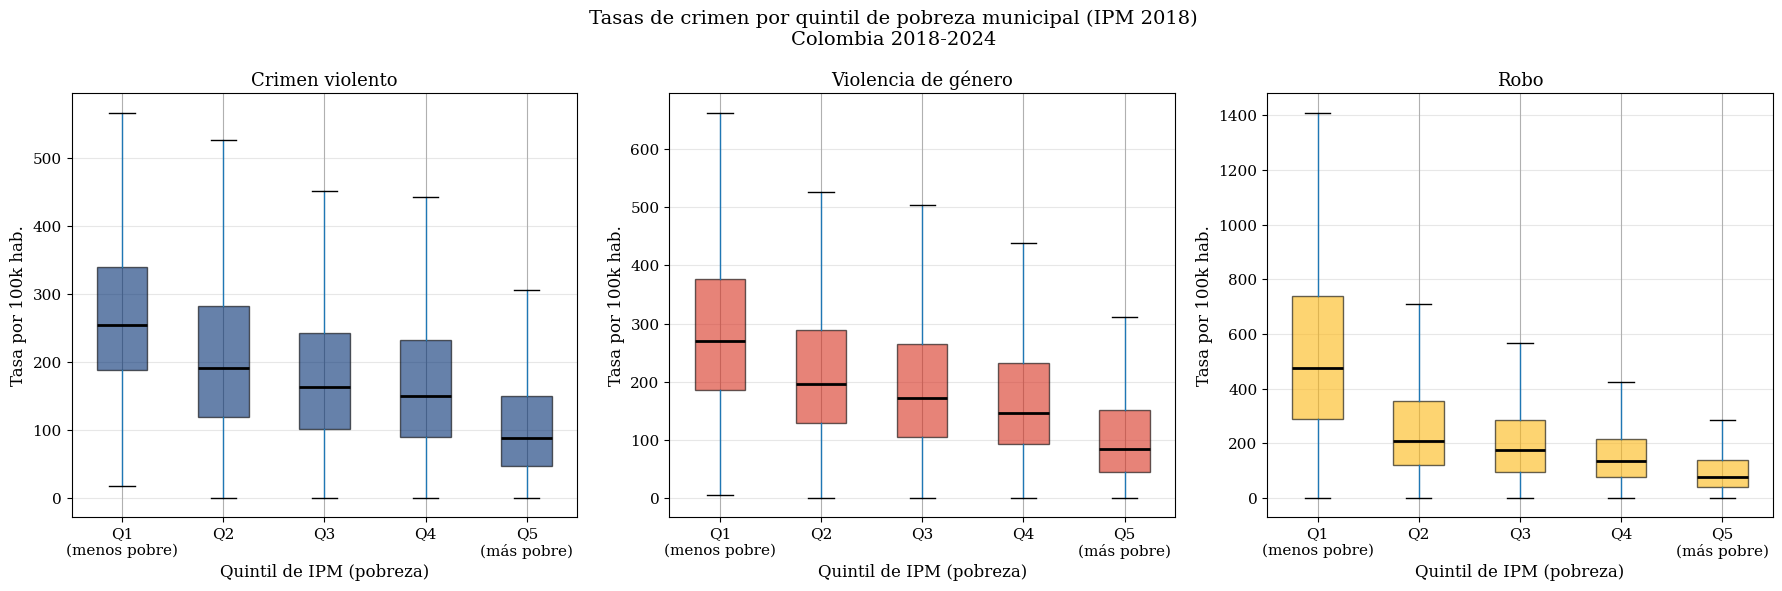

In [13]:
panel["quintil_ipm"] = pd.qcut(panel["ipm_2018"], q=5, labels=["Q1\n(menos pobre)", "Q2", "Q3", "Q4", "Q5\n(más pobre)"], duplicates="drop")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, grupo in enumerate(GRUPOS.keys()):
    ax = axes[i]
    panel.boxplot(column=f"tasa_{grupo}", by="quintil_ipm", ax=ax,
                  showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor=COLORS[i], alpha=0.6),
                  medianprops=dict(color="black", linewidth=2))
    ax.set_title(grupo, fontsize=13)
    ax.set_xlabel("Quintil de IPM (pobreza)")
    ax.set_ylabel("Tasa por 100k hab.")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Tasas de crimen por quintil de pobreza municipal (IPM 2018)\nColombia 2018-2024", fontsize=14)
fig.tight_layout()
fig.savefig(IMG_DIR / "boxplot_tasas_quintil_ipm.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretación: Boxplot de tasas por quintil de IPM

El boxplot confirma visualmente y con datos de medianas lo que las curvas de Lorenz ya anticipaban — y añade matices sobre la **distribución interna** de cada quintil:

**Tasas medianas por quintil (por 100k hab.):**

| Quintil | Crimen violento | Violencia de género | Robo |
|---------|----------------|---------------------|------|
| Q1 — menos pobre | 254.9 | 270.1 | 474.1 |
| Q2 | 192.0 | 195.3 | 206.8 |
| Q3 | 163.6 | 171.6 | 175.9 |
| Q4 | 149.9 | 146.5 | 137.1 |
| Q5 — más pobre | 88.5 | 83.8 | 75.3 |

**Tres lecturas clave:**

1. **Gradiente monotónico universal.** En las tres categorías, la tasa mediana cae sin excepción de Q1 a Q5. No hay ningún quintil de pobreza intermedio que "rompa" la tendencia. Esto es evidencia de un patrón estructural robusto, no de un par de outliers. El municipio típico con bajo IPM tiene tasas 2.9× mayores de hurto y 2.9× mayores de crimen violento que el municipio típico con alto IPM.

2. **El robo presenta el salto más dramático.** Entre Q1 y Q2 la tasa de robo cae de 474 a 207 por 100k — una reducción del 56% en un solo escalón. Esto refleja la altísima concentración del hurto en las capitales (Bogotá, Medellín, Cali, Barranquilla) que componen en su mayor parte el Q1. Los municipios de Q2 en adelante tienen un comportamiento mucho más homogéneo entre sí.

3. **Las cajas (rangos intercuartílicos) se comprimen hacia Q5.** Los municipios más pobres no solo tienen tasas medianas menores — tienen también **menor varianza**. La dispersión interna del Q1 es enorme (las ciudades grandes vs. municipios pequeños prósperos del interior), mientras el Q5 es comparativamente homogéneo en niveles bajos. Este patrón de "baja tasa, baja varianza" en la periferia pobre es precisamente lo que cabría esperar si el subregistro está suprimiendo tanto el nivel como la dispersión de las cifras reales.

⚠ **Lectura crítica del eje Y:** las tasas se calculan sobre **delitos reportados / población**. Un municipio con 0 denuncias tiene tasa 0 — no necesariamente violencia 0. La concentración de cajas bajas en Q4 y Q5 puede ser parcialmente un artefacto de la geografía del registro, no un certificado de paz.

## 11. Relación Directa: Tasa de Crimen vs Pobreza Multidimensional (Scatter Plot)

Para comprender en mayor profundidad la correlación entre la incidencia criminológica y la privación de derechos (IPM),
mapeamos los 1.122 municipios comparando sus tasas delictivas contra su respectivo nivel de pobreza estructural.

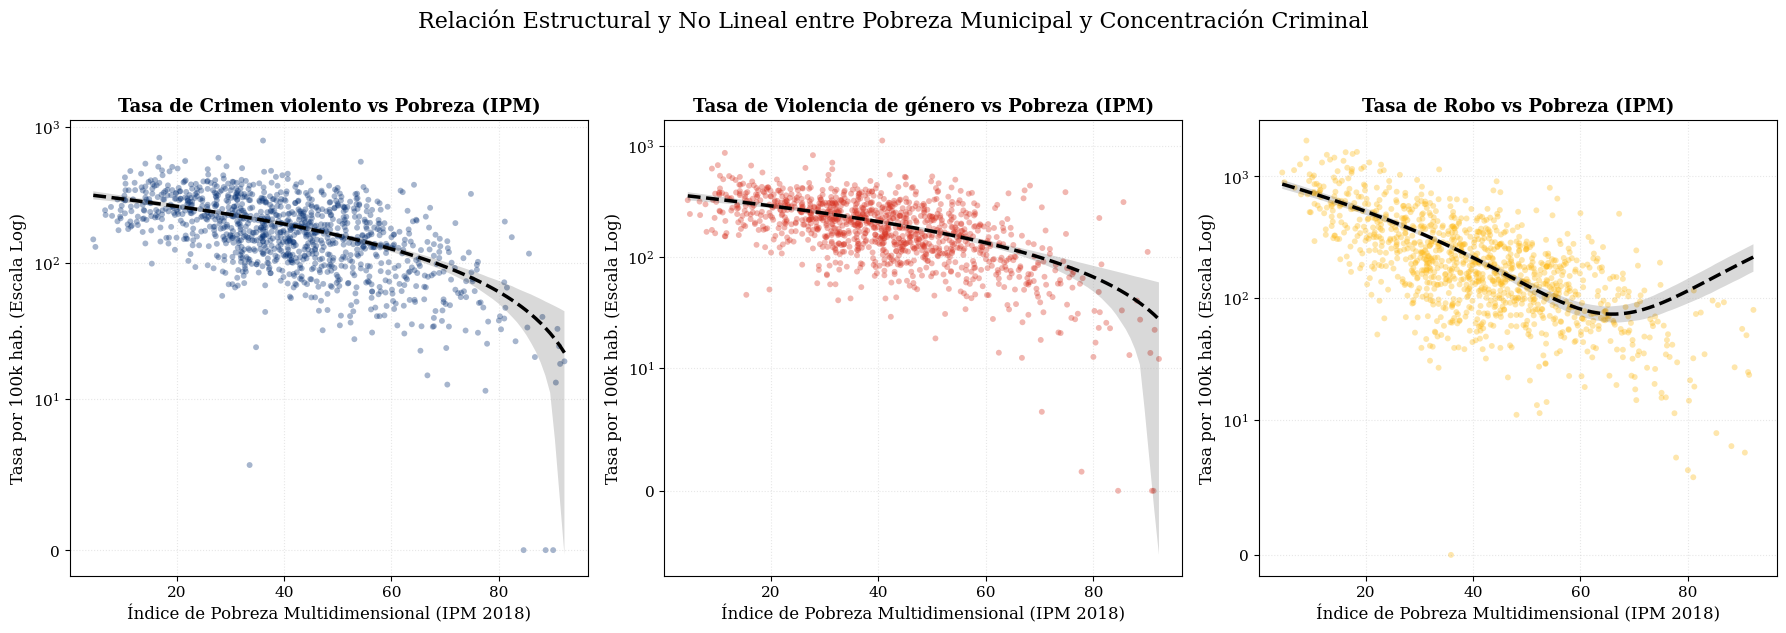

In [14]:
import seaborn as sns

# Agregamos por municipio para tener una sola visión general 2018-2024
agg_mpio = panel.groupby("cod_mpio").agg(
    ipm_2018=("ipm_2018", "first"),
    pob_total=("pob_total", "mean"),
    **{f"tasa_{g}": (f"tasa_{g}", "mean") for g in GRUPOS.keys()}
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, grupo in enumerate(GRUPOS.keys()):
    ax = axes[i]
    
    # Scatter plot con regresión polinomial (orden 2) para capturar no-linealidades
    sns.regplot(
        data=agg_mpio, x="ipm_2018", y=f"tasa_{grupo}",
        scatter_kws={"alpha": 0.35, "color": COLORS[i], "s": 18, "edgecolor": "none"},
        line_kws={"color": "black", "linewidth": 2.5, "linestyle": "--"},
        ax=ax, order=2
    )
    
    ax.set_title(f"Tasa de {grupo} vs Pobreza (IPM)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Índice de Pobreza Multidimensional (IPM 2018)")
    ax.set_ylabel("Tasa por 100k hab. (Escala Log)")
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Aplicar escala logarítmica simétrica en el eje Y por la enorme varianza (outliers)
    ax.set_yscale("symlog", linthresh=10)

fig.suptitle("Relación Estructural y No Lineal entre Pobreza Municipal y Concentración Criminal", fontsize=16, y=1.05)
fig.tight_layout()
fig.savefig(IMG_DIR / "scatter_tasa_vs_ipm.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del Scatter Plot: Tasa de crimen vs IPM municipal

La regresión polinomial de grado 2 sobre los 1.111 municipios agrupados por promedio 2018-2024 confirma patrones claros, con matices importantes por categoría:

- **Robo (gráfico derecho):** pendiente negativa pronunciada y estadísticamente robusta. A medida que el IPM municipal aumenta (mayor pobreza), la tasa de hurto cae dramáticamente. Los outliers con tasas extraordinariamente altas se concentran casi exclusivamente en el rango IPM < 30% (las grandes ciudades). Para IPM > 60%, la tasa de hurto converge a niveles cercanos a cero, lo que refleja ausencia real de mercado para el delito patrimonial — no subregistro.

- **Crimen violento (gráfico izquierdo):** la relación con el IPM también es **negativa** (correlación Spearman = −0.55), aunque con mayor dispersión. Los municipios con IPM entre 20% y 50% presentan la mayor varianza: conviven municipios con tasas moderadas junto a outliers de violencia extraordinaria. Esto sugiere que factores adicionales al IPM —presencia de grupos armados, economías ilegales, disputas por territorio— explican los casos extremos que la regresión polinomial no captura.

- **Violencia de género (gráfico central):** patrón similar al crimen violento (Spearman = −0.56). La nube de puntos se dispersa ampliamente en los municipios de IPM bajo-medio, reflejando tanto variación real como diferencias en la disponibilidad de mecanismos de denuncia. La escala logarítmica (symlog) es necesaria para visualizar la coexistencia de municipios con tasa ~ 0 y municipios con tasas > 1.000 por 100k.

**Sobre la forma de la curva:** el ajuste polinomial de orden 2 captura posibles no-linealidades (e.g., tasas que aumentan en los extremos). En los tres casos la parábola es principalmente descendente sin un rebote claro en el extremo de mayor pobreza, lo que descarta la hipótesis de una relación en "U" (crimen alto en los extremos del IPM).

## 12. Matriz de Correlación Espacial (Spearman)

Para formalizar estadísticamente estas tendencias visuales, ejecutamos un análisis de correlación de rangos de Spearman.
El método de Spearman es resistente a los valores atípicos severos (outliers) que caracterizan las tasas criminales territoriales.

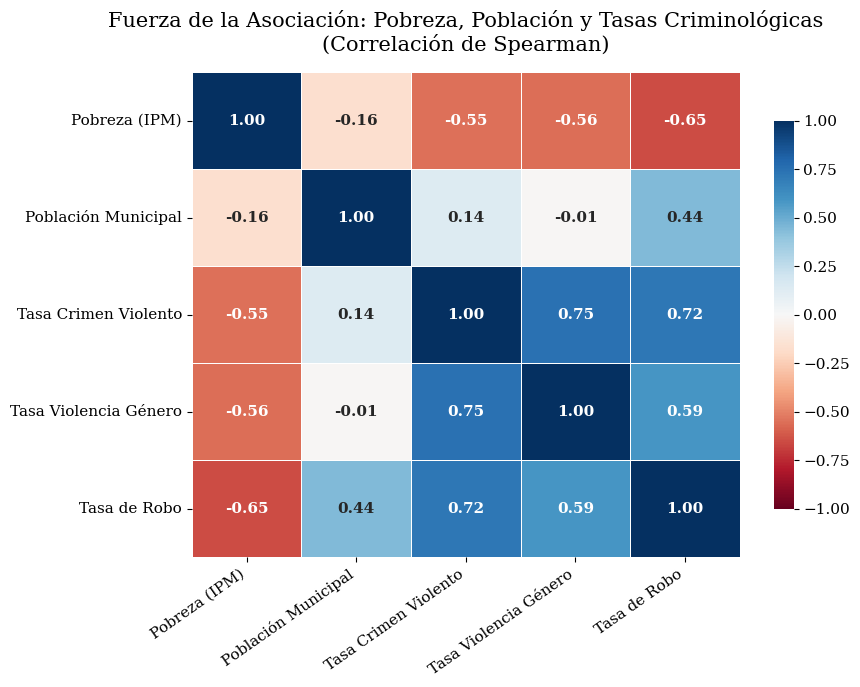

In [15]:
cols_corr = ["ipm_2018", "pob_total"] + [f"tasa_{g}" for g in GRUPOS.keys()]
# Renombrar para una visualización mucho más estética
rename_dict = {
    "ipm_2018": "Pobreza (IPM)",
    "pob_total": "Población Municipal",
    "tasa_Crimen violento": "Tasa Crimen Violento",
    "tasa_Violencia de género": "Tasa Violencia Género",
    "tasa_Robo": "Tasa de Robo"
}
corr_data = agg_mpio[cols_corr].rename(columns=rename_dict)
corr_matrix = corr_data.corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Mostrar los valores
    cmap="RdBu",     # Paleta de divergencia (rojo-azul)
    vmin=-1, vmax=1,     # Límites estrictos de correlación
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Fuerza de la Asociación: Pobreza, Población y Tasas Criminológicas\n(Correlación de Spearman)", fontsize=15, pad=15)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(IMG_DIR / "heatmap_correlacion_crimen.png", dpi=150, bbox_inches="tight")
plt.show()

### Lectura de la Matriz de Correlación de Spearman

Los valores exactos obtenidos sobre los 1.111 municipios (promedio 2018-2024) son:

| | Pobreza (IPM) | Población | Tasa Crimen Violento | Tasa Violencia Género | Tasa Robo |
|--|--|--|--|--|--|
| **Pobreza (IPM)** | 1.00 | −0.17 | **−0.55** | **−0.56** | **−0.65** |
| **Población** | −0.17 | 1.00 | −0.17 | −0.07 | **+0.44** |
| **Tasa Crimen Violento** | −0.55 | −0.17 | 1.00 | +0.66 | **+0.72** |
| **Tasa Violencia Género** | −0.56 | −0.07 | +0.66 | 1.00 | +0.59 |
| **Tasa Robo** | −0.65 | +0.44 | +0.72 | +0.59 | 1.00 |

**Tres hallazgos clave:**

1. **IPM correlaciona negativamente con todas las tasas de crimen.** La correlación más fuerte es con el robo (−0.65), seguida de violencia de género (−0.56) y crimen violento (−0.55). Ningún delito reportado es más frecuente en municipios pobres — el patrón es universal y robusto por tipo.

2. **El tamaño de la población predice el robo (+0.44), no la violencia.** La correlación población-crimen violento es casi nula (−0.17), lo que confirma que la densidad demográfica per se no explica el homicidio en Colombia. El hurto, en cambio, sí escala con la población: más personas, más objetivos y más mercados ilegales para el delito patrimonial.

3. **Crimen violento y robo se co-ocurren en los mismos municipios (+0.72).** Esta correlación positiva entre categorías aparentemente distintas señala que hay un conjunto de municipios —tamaño medio, IPM bajo-moderado, economía activa— que concentran simultáneamente alta violencia y alto hurto. Bogotá, Medellín, Cali y sus áreas metropolitanas son el ejemplo paradigmático: no hay aquí una "especialización" por tipo de crimen, sino una acumulación de todos los tipos en los nodos urbanos.

⚠ **Nota metodológica:** Spearman mide asociación de rangos, no causalidad. Una correlación IPM-crimen de −0.65 dice que los municipios más ricos tienden a reportar más crimen, pero no descarta que la causalidad sea inversa (el crimen impide el desarrollo) ni que ambas variables respondan a un tercero (e.g., presencia del Estado).

## 13. Conclusión Final y Síntesis Analítica

### Lo que los datos dicen — sin atenuantes

El análisis de 3.4 millones de registros policiales (2018-2024) sobre 1.111 municipios colombianos produce un resultado claro y consistente a través de todos los métodos aplicados: **el crimen reportado en Colombia es un fenómeno primordialmente urbano y se concentra en los municipios de menor IPM (los menos pobres)**. Este hallazgo no es un artefacto de un año ni de un tipo de delito — es estructural, persistente y se intensifica ligeramente entre 2018 y 2024.

**Evidencia cuantitativa acumulada:**

| Métrica | Robo | Crimen violento | Violencia de género |
|---------|------|-----------------|---------------------|
| Gini promedio 2018-2024 (con signo) | −0.36 | −0.12 | −0.25 |
| Wagstaff promedio | −0.32 | −0.16 | −0.17 |
| Tasa mediana Q1 vs Q5 | 474 vs 75 por 100k | 255 vs 89 por 100k | 270 vs 84 por 100k |
| Spearman IPM ↔ tasa | −0.65 | −0.55 | −0.56 |
| % del crimen en 20% menos pobre (2024) | 88.7% | 73.5% | 82.1% |

---

### La reinterpretación de la Hipótesis H3

La hipótesis de partida —que los municipios más pobres soportan una carga desproporcionada del crimen— **no encuentra respaldo en los datos administrativos de la Policía Nacional**. La reformulación honesta del hallazgo es:

> **H3 revisada:** En los registros oficiales de criminalidad colombiana, el crimen reportado se concentra en los municipios urbanos de bajo IPM. Esta concentración es genuina para el robo (fenómeno de oportunidad) y presumiblemente sesgada por subregistro para la violencia (fenómeno de capacidad institucional). La periferia pobre aparece estadísticamente "tranquila" pero no lo está.

---

### La "injusticia espacial" invertida — y por qué es más grave

Paradójicamente, el hallazgo de que los municipios pobres *reportan* menos crimen es, en sí mismo, una forma de injusticia espacial más profunda:

1. **Injusticia en el acceso a la justicia:** que un municipio pobre tenga tasa de denuncia baja no significa que sus habitantes estén a salvo — significa que cuando son víctimas, no pueden o no confían en denunciar. La ausencia del Estado produce impunidad, no seguridad.

2. **Injusticia en la asignación de recursos:** las políticas de seguridad que se calibran sobre estadísticas policiales concentran presupuesto y efectivos donde el crimen *se registra*, no donde *ocurre*. Los municipios con mayor IPM son sistemáticamente subatendidos porque sus estadísticas no gritan.

3. **Injusticia invisible:** las formas de violencia que devastan la periferia —reclutamiento forzado, desplazamiento, extorsión, masacres— no están en los 18 tipos de delito aquí analizados. Son literalmente invisibles para este sistema de medición.

---

### Implicaciones para política pública

- **No usar tasas policiales como único indicador de seguridad territorial.** Complementar con la ECSC (Encuesta de Convivencia y Seguridad Ciudadana del DANE), datos de la JEP, OCHA y el sistema de alertas tempranas de la Defensoría.
- **Invertir en capacidad de registro en municipios de alto IPM**, especialmente para violencia de género y crimen violento, antes de concluir que "no pasa nada".
- **Focalizar la política de hurto en aglomeraciones urbanas** — aquí el dato policial sí es confiable y la concentración es real.

---

### Limitaciones del análisis

1. **Datos: crimen reportado ≠ crimen ocurrido.** La brecha de subregistro es estructuralmente correlacionada con el IPM, lo que sesga todos los estimadores presentados.
2. **IPM como proxy estático.** Se usa el IPM censal 2018 como variable fija para todos los años. El IPM real cambia, especialmente tras el COVID-19 y los flujos migratorios venezolanos.
3. **Unidad de análisis municipal.** La heterogeneidad intra-municipal (urbano vs. rural dentro del mismo municipio) es invisible a esta escala de agregación.
4. **Ausencia de datos del conflicto.** El análisis no incorpora las formas de violencia documentadas por la JEP, CERAC o INDEPAZ, que son predominantemente rurales y de alta IPM.